# Laptop Version Analysis
## Significant variables were established in SQL and now will have been done describing statistic.
## In describing statistic, the variables will be understood.

In [18]:
# Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sbn

In [10]:
# Dataframe
import pyodbc

server = r"(localdb)\MSSQLLocalDB"
database = "LaptopPriceAnalysis"
driver = "ODBC Driver 17 for SQL Server"

connection_string = (
    f"DRIVER={{{driver}}};"
    f"SERVER={server};"
    f"DATABASE={database};"
    "Trusted_Connection=yes;"
)

print(connection_string)  

conn = pyodbc.connect(connection_string)
print("Connection Succesful")


DRIVER={ODBC Driver 17 for SQL Server};SERVER=(localdb)\MSSQLLocalDB;DATABASE=LaptopPriceAnalysis;Trusted_Connection=yes;
Connection Succesful


In [11]:
query = "SELECT * FROM dbo.Laptops_Final_Analysis"
df = pd.read_sql(query, conn)

df.head()


C:\Users\Yusuf\AppData\Local\Temp\ipykernel_17744\1377585449.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


,Laptop_ID,Discounted_Price,Actual_Price,Rating,Reviews,Brand,Core,SSD,Series,Processor,RAM,Storage
0,0,2034990.0,2580000.0,5.0,2.0,Apple,M1,None,MacBook,Apple M1,8GB,256GB SSD
1,1,2819990.0,3500000.0,43.0,5.0,Apple,M4,None,MacBook,None,None,None
2,2,2859990.0,3300000.0,NaN,NaN,ASUS,Ultra 7,16GB-512GB SSD,Zenbook,Intel Core Ultra 7,16GB,512GB SSD
3,3,2879990.0,3400000.0,NaN,NaN,Lenovo,Ultra 7,None,ThinkPad,Intel Core Ultra 7,16GB,512GB SSD
4,4,1469990.0,1750000.0,NaN,NaN,Lenovo,Ryzen 7,None,IdeaPad,AMD Ryzen 7,8GB,512GB SSD


In [12]:
# Looking summary for numeric variables
df.describe()

,Laptop_ID,Discounted_Price,Actual_Price,Rating,Reviews
count,306.000000,3.060000e+02,2.910000e+02,26.000000,26.000000
mean,152.500000,2.775879e+06,3.212616e+06,9.461538,1.615385
std,88.478811,1.708020e+06,1.802598e+06,13.243053,1.134087
min,0.000000,8.599900e+05,1.119990e+06,3.000000,1.000000
25%,76.250000,1.742490e+06,2.000000e+06,5.000000,1.000000
50%,152.500000,2.344990e+06,2.800000e+06,5.000000,1.000000
75%,228.750000,3.449998e+06,3.800000e+06,5.000000,2.000000
max,305.000000,1.552999e+07,1.599900e+07,48.000000,5.000000


# Numeric variables showed that: 
    Discount_Price mean and median (50%) near (The two values have 10% difference almost). ALso, quartiles distribution not normal.
    1st and 2nd (median) have 600.000 gaps but 2nd and 3rd have 1.100.000 gaps. So Discount price look like don't have normal distribution.
    Probably it's right skewed a distribution.
    Min and Max values far from quartiles. That's showed the variable can be has outlier values.
    Std. deviasion smaller than mean almost 1m points. That shows it hasn't normal distribution.

    Actual_Price mean and median near (10%). That's normal.
    Quartiles far but balanced. This mean is this distribution probably has kurtosis a distribution.
    1st quartile has near distance Min value and median but max value not has same distance with median and max value.
    This variable can has maximal side outlier values.
    Std. deviasion and mean has bigger distance. So this variable hasn't skewed distribution.

    Rating median value almost half of mean. So that mean is outlier values inflate to mean and the outlier values establish skewd distribution.
    Quartiles have same values. This shows the variable has same value (5) repeat much time.
    Min value acceptable but max value have a big distance from 3rd quartile.
    Std. deviasion is bigger than mean and that shows a skewnes and the skewnes probably ridght side of the distribution.

    Reviews mean and median have big distance. That shows a skewnes.
    1st and 2nd quartiles have same value but 3rd quartile both of them 2 times more. Probably this distirbution right skewed a distribution.
    Min is same value 1st and 2nd quartiles but max value is 2.5 times more than 3rd quartile. This promotes ridght skewed distribution.
    Std. deviasion and mean have big distance. This promotes to skewness.

In [15]:
# Looking summary for categorical variables
cat_cols = ["Brand", "Core", "SSD", "Series", "Processor", "RAM", "Storage"]
for col in cat_cols:
    freq = df[col].value_counts()
    ratio = df[col].value_counts(normalize=True) * 100
    
    freq_table = pd.DataFrame({
        "Frekans": freq,
        "Yüzde (%)": ratio.round(2)
    })
    
    print(f"\n--- {col} ---")
    display(freq_table)


--- Brand ---


,Frekans,Yüzde (%)
Brand,,
HP,110,35.95
Lenovo,75,24.51
ASUS,28,9.15
Dell,28,9.15
Apple,21,6.86
LENOVO,13,4.25
Acer,12,3.92
Infinix,7,2.29
Asus,6,1.96



--- Core ---


,Frekans,Yüzde (%)
Core,,
Core i7,50,22.83
Core i5,45,20.55
Ultra 7,32,14.61
Ultra 5,17,7.76
Core i3,13,5.94
Ultra 9,12,5.48
Ryzen 5,11,5.02
M3,9,4.11
Ryzen 7,7,3.20



--- SSD ---


...

,Frekans,Yüzde (%)
Processor,,
Intel Core i7,79,30.38
Intel Core i5,69,26.54
Intel Core Ultra 7,33,12.69
Intel Core Ultra 5,18,6.92
Intel Core i3,17,6.54
AMD Ryzen 5,11,4.23
Apple M3,9,3.46
Intel Core i9,9,3.46
AMD Ryzen 7,8,3.08



--- RAM ---


,Frekans,Yüzde (%)
RAM,,
8GB,133,54.96
16GB,83,34.30
32GB,18,7.44
4GB,7,2.89
64GB,1,0.41



--- Storage ---


,Frekans,Yüzde (%)
Storage,,
512GB SSD,172,68.8
1TB SSD,54,21.6
256GB SSD,18,7.2
2TB SSD,6,2.4


## Interpretation:
    HP and Lenovo have half of the market.
    
    Intel cores so popular. i7 and i5 the best and when appended i9 is establishes half of the market.
    Ultra serieses so popular in the market.

    512 GB SSDS includes bigger area. It establishes almost 90% to the market.

    8gb Rams so popular. It prefers so much but 16gb rams saling not small. 8gb and 16gb rams dominant to the market.

    512gb storages prefers. Bigger than values not important for to the users.

In [16]:
# Visulation to the graphs

## Describing variable for drawing

numCols = ["Discounted_Price", "Actual_Price", "Rating", "Reviews"]

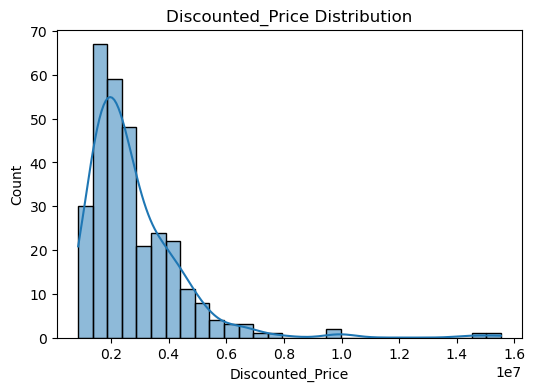

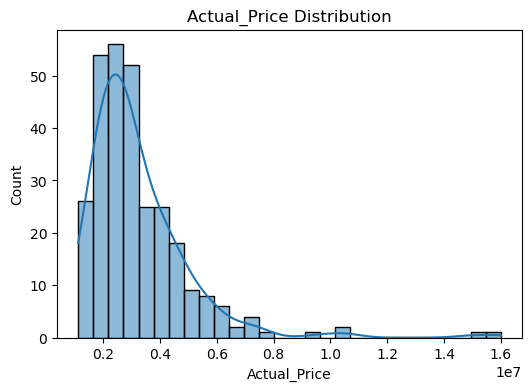

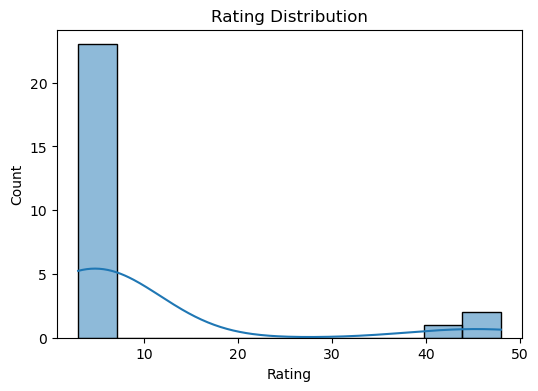

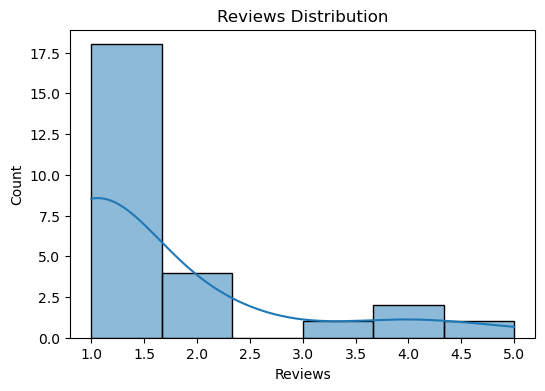

In [21]:
## Histograms

for col in numCols:
    plt.figure(figsize=(6, 4))
    sbn.histplot(df[col], kde=True)
    plt.title(f"{col} Distribution")
    plt.show()

## Interpretation:
    All of the graphs show right skewed distirbution.
    Discounted_Price and Actual_Price look like show same skewnes. So the two variables could be correlation.
    Rating and Reviews have a gap. This increases asimetric distribution and probably reason of the skewnes.

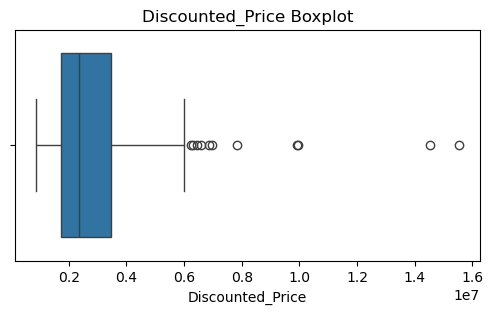

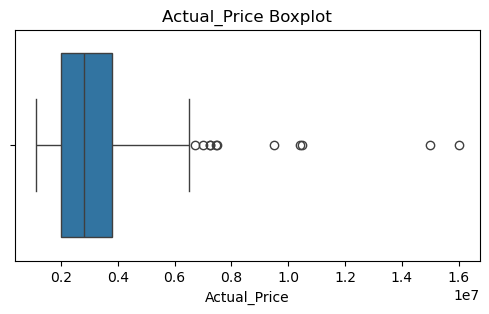

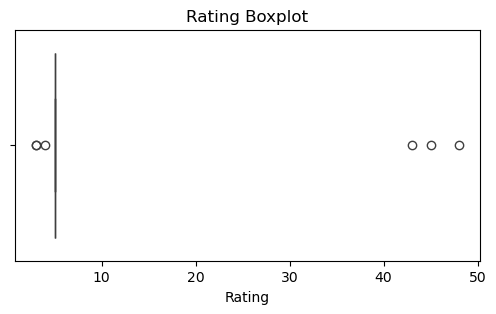

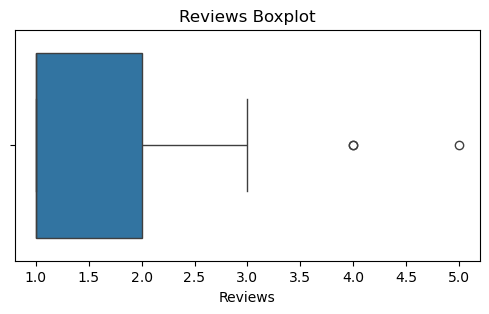

In [22]:
# Boxplot

for col in numCols:
    plt.figure(figsize=(6, 3))
    sbn.boxplot(x=df[col])
    plt.title(f"{col} Boxplot")
    plt.show()

## Interpretation:
    Discounted_Price and Actual_Price 1st quartile distance narrow. Same and more narrow have other variables. 
    Discounted_Price and Actual_Price have many outlier values and this is main reason for skewness.
    Rating haven't any distribution and this mean is probably it hasn't any impress for the any variables.

<function matplotlib.pyplot.show(close=None, block=None)>

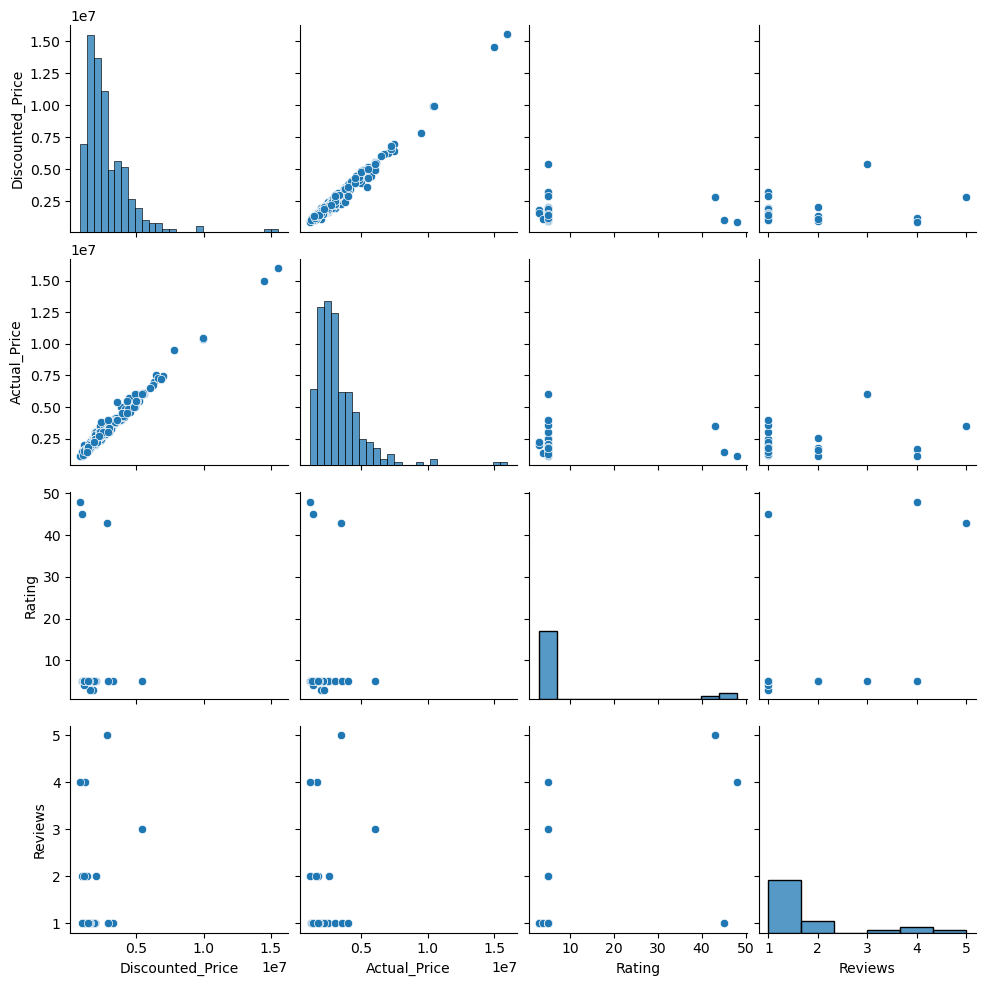

In [24]:
## Relaiton Graphs

sbn.pairplot(df[numCols])
plt.show

## Interpretation:
    This graphs show intensity. 

    Discounted Price can be 2 groups. High discounted and normal discounted. Outlier  are high discounted, main distribution is normal discounted group.
    For Actual Price can be 3 groups. These are low, middle and high but low prices weighted.
    Rating can be 2 groups. Low (5) and high (outlier).
    Reviews can be 2 groups. Low and high (outlier).

In [26]:
# Chisquare indepented tests for categorical tests

## Library 

from scipy.stats import chi2_contingency
import itertools

In [30]:
## Chisquare test

results = []

for col1, col2 in itertools.combinations(cat_cols, 2):
    contingency = pd.crosstab(df[col1], df[col2])

    if contingency.shape[0] > 1 and contingency.shape[1] > 1:
        chi2, p, dof, expected = chi2_contingency(contingency)
        
        results.append({
            "Variable_1": col1,
            "Variable_2": col2,
            "Chi2": chi2,
            "p_value": p,
            "Independent": "No" if p < 0.05 else "Yes"
        })

chiSquareResults = pd.DataFrame(results)

chiSquareResults.sort_values("p_value")

,Variable_1,Variable_2,Chi2,p_value,Independent
8,Core,Processor,2403.371212,0.000000e+00,No
2,Brand,Series,1909.027226,1.652439e-248,No
7,Core,Series,993.051749,3.017044e-52,No
15,Series,Processor,778.720797,3.111180e-44,No
3,Brand,Processor,405.234194,5.729373e-36,No
20,RAM,Storage,192.439176,1.181464e-34,No
13,SSD,RAM,223.772727,6.852728e-33,No
0,Brand,Core,468.361997,5.208886e-32,No
10,Core,Storage,212.032790,1.672094e-23,No
19,Processor,Storage,148.849250,1.138648e-15,No


## Interpretation:
    Expect Brand RAM, Brand SSD, Brand Storage every variable depented together.
    The variables had been established in SQL from Name column.
    This shows every brand produces self piece of computers and due to every brand have different pieces. Thus any independent can't be seen.
    But RAM, SSD, Storage can be independent from brand. Because the all brands use same pieces for self computers.

In [31]:
## Test of normality

from scipy.stats import shapiro

for col in numCols:
    stat, p = shapiro(df[col].dropna())
    print(f"{col}: p-value = {p: .5f}")

Discounted_Price: p-value =  0.00000
Actual_Price: p-value =  0.00000
Rating: p-value =  0.00000
Reviews: p-value =  0.00000


In [32]:
## Test of homogenity

from scipy.stats import levene

groups = [
    df[df["Brand"] == brand] ["Discounted_Price"].dropna()
    for brand in df["Brand"].unique()
]

stat, p = levene(*groups)
print("Levene p-value: ", p)

Levene p-value:  0.5851295489277011


## Interpretation:
    Numeric variables can't ensured normality but the variables have homogenity.

In [34]:
## Correlation test

## Numeric variables have asimetric distribution. Therefore can't done Pearson correlation.
## Instead non-parametric alternative spearman correlation test will be done.

df[numCols].corr(method="spearman")

,Discounted_Price,Actual_Price,Rating,Reviews
Discounted_Price,1.000000,0.975745,-0.153835,-0.056209
Actual_Price,0.975745,1.000000,-0.132057,-0.025168
Rating,-0.153835,-0.132057,1.000000,0.409763
Reviews,-0.056209,-0.025168,0.409763,1.000000


## Interpretation:
    Discount_Price and Actual_Price have powerfull positive correlation.
    Discount_Price has not powerfull correlation with Rating and Reviews. So the variables impress to discount limited.

    Rating and Reviews impress Actual_Price how limited.

    Rating and Reviews have normal correlation.

<function matplotlib.pyplot.show(close=None, block=None)>

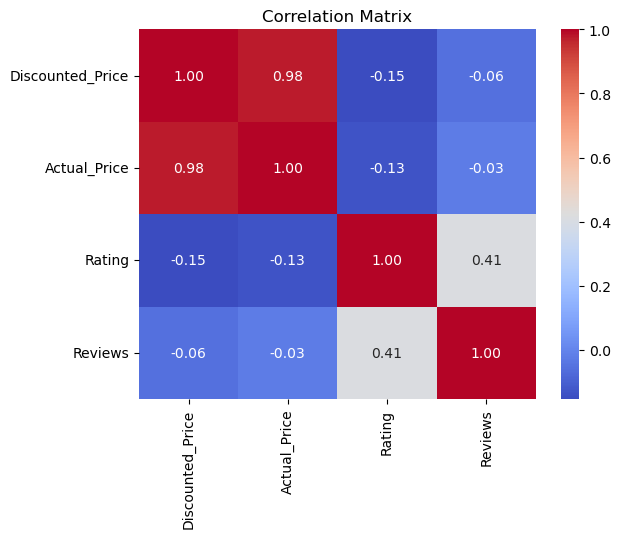

In [35]:
## Correlation Graph

sbn.heatmap(
    df[numCols].corr(method="spearman"),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("Correlation Matrix")
plt.show

In [43]:
## Categorical variables and numeric variables significant test
from skbio.stats.distance import permanova, DistanceMatrix
from scipy.spatial.distance import pdist, squareform
from skbio.stats.distance import permdisp 

In [48]:
dm = DistanceMatrix(
    squareform(pdist(X_filled, metric='euclidean')),
    ids=X_filled.index.astype(str)  # ID’leri string yap, grouping ile eşleşsin
)

In [49]:
grouping = df[factor].fillna("Missing").astype(str)


In [51]:
X_filled = df[numCols].fillna(df[numCols].median())

X_filled.index = X_filled.index.astype(str)
dm = DistanceMatrix(squareform(pdist(X_filled, metric='euclidean')), ids=X_filled.index)

final_results = []

for factor in cat_cols:
    grouping = df[factor].fillna("Missing").astype(str)
    grouping.index = grouping.index.astype(str)
    perm = permanova(dm, grouping, permutations=999)
    disp = permdisp(dm, grouping, permutations=999)

    if perm["p-value"] < 0.05 and disp["p-value"] >= 0.05:
        decision = "Significant (clean)"
    elif perm["p-value"] < 0.05 and disp["p-value"] < 0.05:
        decision = "Significant (dispersion issue)"
    else:
        decision = "Not significant"

    final_results.append({
        "factor": factor,
        "permanova_p": perm["p-value"],
        "permdisp_p": disp["p-value"],
        "decision": decision
    })
    
results_df = pd.DataFrame(final_results)
results_df = results_df.sort_values("permanova_p").reset_index(drop=True)

print(results_df)

      factor  permanova_p  permdisp_p                        decision
0      Brand        0.001       0.420             Significant (clean)
1       Core        0.001       0.002  Significant (dispersion issue)
2     Series        0.001       0.002  Significant (dispersion issue)
3  Processor        0.001       0.001  Significant (dispersion issue)
4    Storage        0.001       0.001  Significant (dispersion issue)
5        RAM        0.001       0.312             Significant (clean)
6        SSD        0.070       0.111                 Not significant


## Interpretation:
    According to results, except SSD variables have significant differences for Discounted_Price, Actual_Price, Reviews, and Rating.
    But probably Reviews and Rating no have significant impress. Therefore pot-hoc test will be done.

### RESULT INTERPRETATION:
    According to results, numeric variables that Discounted_Price, Actual_Price, Rating, and Reviews no have normal distribution but those have homogenity.
    Categorical variables depenced each other. This main reason (most probably) this variables were ensured whil data cleaning in SQL from Name column (ETL). But though that, found indepency between brand with RAM, SSD, Storage.
    According to the result, other variables impress to the each other values but brand and RAM, brand and SSD, brand and Storage don't impress each other. So inferential statistic stage, mostly will have been used brand, RAM, SSD, Storage categorical variables.
    Reviews and Rating can't explain any results. Because couldn't have found any correlation for Actual_Price and Discounted_Price.
    PERMANOVA test that maden except SSD found significant results but probably Reviews and Rating can't ensure this significanty. Probably ensures this significanty Discounted_Price and Actual_Price.
    SSD doesn't has a significanty for numeric variables. Probably that's reason that ensuring 512gb SSDs ensuring 2/3 and with 1tb SSDs ensuring 9/10.